# Probabilistic forecast evaluation

This notebook shows how to use `ForecastPerformance` to evaluate **probabilistic forecasts** with a suite of skill metrics.

In [35]:
import pandas as pd
from pathlib import Path
from performance import ForecastPerformance, Results 

test_dataset_path = Path(r'tests\test_datasets_daily')

obs_path = test_dataset_path / 'obs.parquet'
obs = pd.read_parquet(obs_path)
display(obs.head(5))

prob_path = test_dataset_path / 'prob.parquet'
prob = pd.read_parquet(prob_path)
display(prob.head(5))

,Q
event_datetime,
2016-10-06,889.21256
2016-10-07,881.77048
2016-10-08,872.04598
2016-10-09,855.84720
2016-10-10,868.49997


Q
event_datetime non_exceedance leadtime production_datetime             
2016-10-06     0.02           1 days   2016-10-05            993.811707
                              2 days   2016-10-04           1022.668031
                              3 days   2016-10-03           1051.524354
                              4 days   2016-10-02           1072.782685
                              5 days   2016-10-01           1094.041016

In [36]:
fp = ForecastPerformance(obs)

fp.add(prob, name='probabilistic')

expected = fp.get_expected_prediction(name='probabilistic')
expected.columns = ['expected']
fp.add(expected, name='expected')
display(expected.head(5))

median = prob.unstack('non_exceedance').droplevel(0, axis=1).loc[:, [0.4, 0.6]].mean(axis=1).to_frame(name='median')
fp.add(median, name='median')

display(median.head(5))

expected
production_datetime event_datetime leadtime            
2016-09-26          2016-10-06     10 days   937.005345
2016-09-27          2016-10-06     9 days    933.933947
                    2016-10-07     10 days   934.107754
2016-09-28          2016-10-06     8 days    930.862550
                    2016-10-07     9 days    938.438844

median
event_datetime leadtime production_datetime            
2016-10-06     1 days   2016-10-05           886.494415
               2 days   2016-10-04           901.896810
               3 days   2016-10-03           917.299204
               4 days   2016-10-02           934.520024
               5 days   2016-10-01           951.740845

In [37]:
results = Results('Model', 'Metric', 'Leadtime')

for model in fp.names():
    print(f'{model}')
    for metric in [fp.KGEprime, fp.NSE, fp.RMSE, fp.MAE, fp.bias, fp.relative_bias, fp.Pearson]:
        for leadtime in median.index.get_level_values('leadtime').unique():
            results.append(Model=model, Metric=metric.__name__, Leadtime=leadtime,
                        Value=fp.deterministic(metric, model, leadtime=leadtime),
                        )
        
df = results.to_pandas(index=['Leadtime', 'Model'], columns=['Metric'])
display(df)

probabilistic
expected
median


Value                                            \
Metric                       bias kge_prime         mae       nse   pearson   
Leadtime Model                                                                
1 days   expected       -9.256175  0.988930   60.724571  0.988821  0.994474   
         median        -10.903015  0.988476   61.070122  0.988712  0.994427   
         probabilistic  -9.256175  0.988930   60.724571  0.988821  0.994474   
2 days   expected      -16.010713  0.982319   96.958926  0.970030  0.985017   
         median        -19.313644  0.980916   96.757657  0.970129  0.985118   
         probabilistic -16.010713  0.982319   96.958926  0.970030  0.985017   
3 days   expected      -22.369120  0.960528  151.953361  0.925455  0.962484   
         median        -27.312002  0.959181  151.324010  0.925798  0.962641   
         probabilistic -22.369120  0.960528  151.953361  0.925455  0.962484   
4 days   expected      -24.699121  0.942480  182.842379  0.893128  0.945743   
         median        -30.137078  0.940892  182.288759  0.893178  0.945751   
         probabilistic -24.699121  0.942480  182.842379  0.893128  0.945743   
5 days   expected      -26.939302  0.914934  226.221847  0.836393  0.916780   
         median        -32.859828  0.913995  225.542312  0.836555  0.916719   
         probabilistic -26.939302  0.914934  226.221847  0.836393  0.916780   
6 days   expected      -33.851130  0.899453  234.797331  0.823045  0.908567   
         median        -40.052948  0.898350  234.371047  0.822402  0.908298   
         probabilistic -33.851130  0.899453  234.797331  0.823045  0.908567   
7 days   expected      -40.762957  0.875310  254.721710  0.790369  0.890593   
         median        -47.246069  0.874790  254.646003  0.789013  0.890053   
         probabilistic -40.762957  0.875310  254.721710  0.790369  0.890593   
8 days   expected      -47.544075  0.847533  282.912403  0.739277  0.862780   
         median        -54.311122  0.847550  283.085357  0.737315  0.862017   
         probabilistic -47.544075  0.847533  282.912403  0.739277  0.862780   
9 days   expected      -54.396371  0.828187  288.578349  0.727964  0.855541   
         median        -62.691852  0.827404  288.505681  0.726369  0.854996   
         probabilistic -54.396371  0.828187  288.578349  0.727964  0.855541   
10 days  expected      -60.835583  0.805593  302.837510  0.698438  0.838580   
         median        -70.645377  0.803327  302.708518  0.696501  0.837883   
         probabilistic -60.835583  0.805593  302.837510  0.698438  0.838580   

                                                  
Metric                 relative_bias        rmse  
Leadtime Model                                    
1 days   expected          -0.004780  113.132864  
         median            -0.005630  113.687702  
         probabilistic     -0.004780  113.132864  
2 days   expected          -0.008267  185.242372  
         median            -0.009973  184.935987  
         probabilistic     -0.008267  185.242372  
3 days   expected          -0.011580  291.322003  
         median            -0.014139  290.650986  
         probabilistic     -0.011580  291.322003  
4 days   expected          -0.012786  348.815302  
         median            -0.015602  348.733735  
         probabilistic     -0.012786  348.815302  
5 days   expected          -0.013968  431.121859  
         median            -0.017037  430.907503  
         probabilistic     -0.013968  431.121859  
6 days   expected          -0.017551  448.362846  
         median            -0.020767  449.177698  
         probabilistic     -0.017551  448.362846  
7 days   expected          -0.021135  488.007686  
         median            -0.024496  489.583232  
         probabilistic     -0.021135  488.007686  
8 days   expected          -0.024686  543.697159  
         median            -0.028200  545.738817  
         probabilistic     -0.024686  543.697159  
9 days   expected          -0.028244  555.3

In [40]:
results = Results('Model', 'Metric', 'Leadtime')

metrics = ['crps', 'fair_crps', 'quantile_loss', 'reliability', 'resolution']
fp.add(prob + 100, name='probabilistic + 100')
fp.add(prob * 0.95, name='probabilistic * 0.95')

for model in [n for n in fp.names() if n.startswith('probabilistic')]:
    print(f'{model}')
    for metric in metrics:
        for leadtime in prob.index.get_level_values('leadtime').unique():
            results.append(Model=model, Metric=metric, Leadtime=leadtime,
                        Value=fp.probabilistic(metric, model, leadtime=leadtime),
                        )

df = results.to_pandas(index=['Metric', 'Model'], columns=['Leadtime'])
display(df)

probabilistic


c:\Users\zepedro\Documents\GitHub\forecast_performance\performance\forecast_performance.py:771: UserWarning: Boundaries of the probabilistic forecast are incomplete (not [0,1]).
  warnings.warn(
c:\Users\zepedro\Documents\GitHub\forecast_performance\performance\metrics\probabilistic.py:219: RuntimeWarning: divide by zero encountered in divide
  b = (y1 - y0) / (x1 - x0)
c:\Users\zepedro\Documents\GitHub\forecast_performance\performance\metrics\probabilistic.py:223: RuntimeWarning: invalid value encountered in add
  np.power(a + b * x1, 3) - np.power(a + b * x0, 3)


probabilistic + 100
probabilistic * 0.95


Value                          \
Leadtime                               1 days      2 days      3 days   
Metric        Model                                                     
crps          probabilistic         49.170605   78.035359  123.607989   
              probabilistic * 0.95  96.593072  114.774436  149.256131   
              probabilistic + 100   93.464638  112.027833  149.530626   
fair_crps     probabilistic         49.170605   78.035359  123.607989   
              probabilistic * 0.95  96.593072  114.774436  149.256131   
              probabilistic + 100   93.464638  112.027833  149.530626   
quantile_loss probabilistic         19.291865   30.777834   49.609299   
              probabilistic * 0.95  38.895773   45.494567   60.209627   
              probabilistic + 100   37.527969   44.062741   59.800593   
reliability   probabilistic          0.896792    0.900449    0.860962   
              probabilistic * 0.95   0.212693    0.353797    0.485901   
              probabilistic + 100    0.241687    0.370884    0.479313   
resolution    probabilistic          0.025395    0.018899    0.015417   
              probabilistic * 0.95   0.026732    0.019894    0.016228   
              probabilistic + 100    0.025395    0.018899    0.015417   

                                                                        \
Leadtime                                4 days      5 days      6 days   
Metric        Model                                                      
crps          probabilistic         148.047381  183.905062  189.032146   
              probabilistic * 0.95  169.165664  200.003687  205.878134   
              probabilistic + 100   171.289706  204.207924  207.901135   
fair_crps     probabilistic         148.047381  183.905062  189.032146   
              probabilistic * 0.95  169.165664  200.003687  205.878134   
              probabilistic + 100   171.289706  204.207924  207.901135   
quantile_loss probabilistic          58.909708   73.482664   74.614477   
              probabilistic * 0.95   67.934349   80.803247   82.204073   
              probabilistic + 100    67.853344   81.221574   81.774078   
reliability   probabilistic           0.855171    0.834473    0.843251   
              probabilistic * 0.95    0.548349    0.604346    0.622519   
              probabilistic + 100     0.529521    0.571167    0.592655   
resolution    probabilistic           0.013525    0.012123    0.011268   
              probabilistic * 0.95    0.014237    0.012761    0.011861   
              probabilistic + 100     0.013525    0.012123    0.011268   

                                                                        \
Leadtime                                7 days      8 days      9 days   
Metric        Model                                                      
crps          probabilistic         204.827706  228.306341  230.114567   
              probabilistic * 0.95  221.333396  243.275614  246.093111   
              probabilistic + 100   221.638751  243.329873  243.961687   
fair_crps     probabilistic         204.827706  228.306341  230.114567   
              probabilistic * 0.95  221.333396  243.275614  246.093111   
              probabilistic + 100   221.638751  243.329873  243.961687   
quantile_loss probabilistic          80.601533   90.309665   89.983807   
              probabilistic * 0.95   88.101309   97.363449   97.372140   
              probabilistic + 100    87.032083   95.951123   95.248880   
reliability   probabilistic           0.839036    0.832112    0.835836   
              probabilistic * 0.95    0.641208    0.657408    0.662769   
              probabilistic + 100     0.617953    0.637387    0.654233   
resolution    probabilistic           0.010547    0.009944    0.009432   
              probabilistic * 0.95    0.011102    0.010467    0.009929   
              probabilistic + 100     0.010547    0.009944    0.009432   

                                                
Leadtime  

,uniform,p_values,leadtime
0,0.000000,0.0,1 days
1,0.000367,0.0,1 days
2,0.000734,0.0,1 days
3,0.001101,0.0,1 days
4,0.001468,0.0,1 days
...,...,...,...
27749,0.998577,1.0,10 days
27750,0.998933,1.0,10 days
27751,0.999289,1.0,10 days
27752,0.999644,1.0,10 days


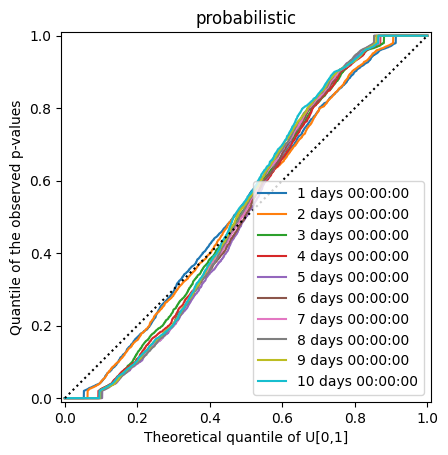

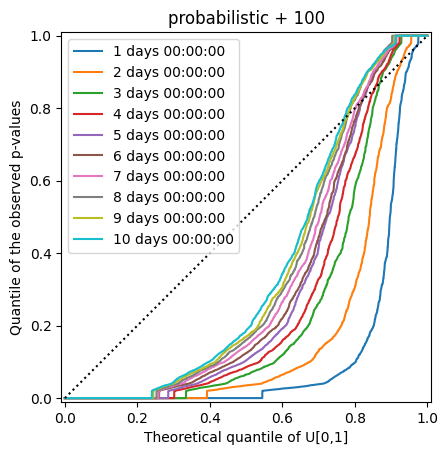

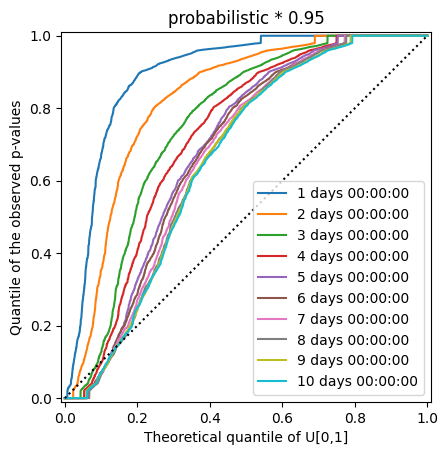

In [41]:
qq = fp.qq_plot(name='probabilistic')
_ = fp.qq_plot(name='probabilistic + 100')
_ = fp.qq_plot(name='probabilistic * 0.95')
display(qq)